# SA calibration factor CI-APi-ToFs

@author: Cecilia Righi

## SMEAR II - Hyytiälä

### APi-ToF3

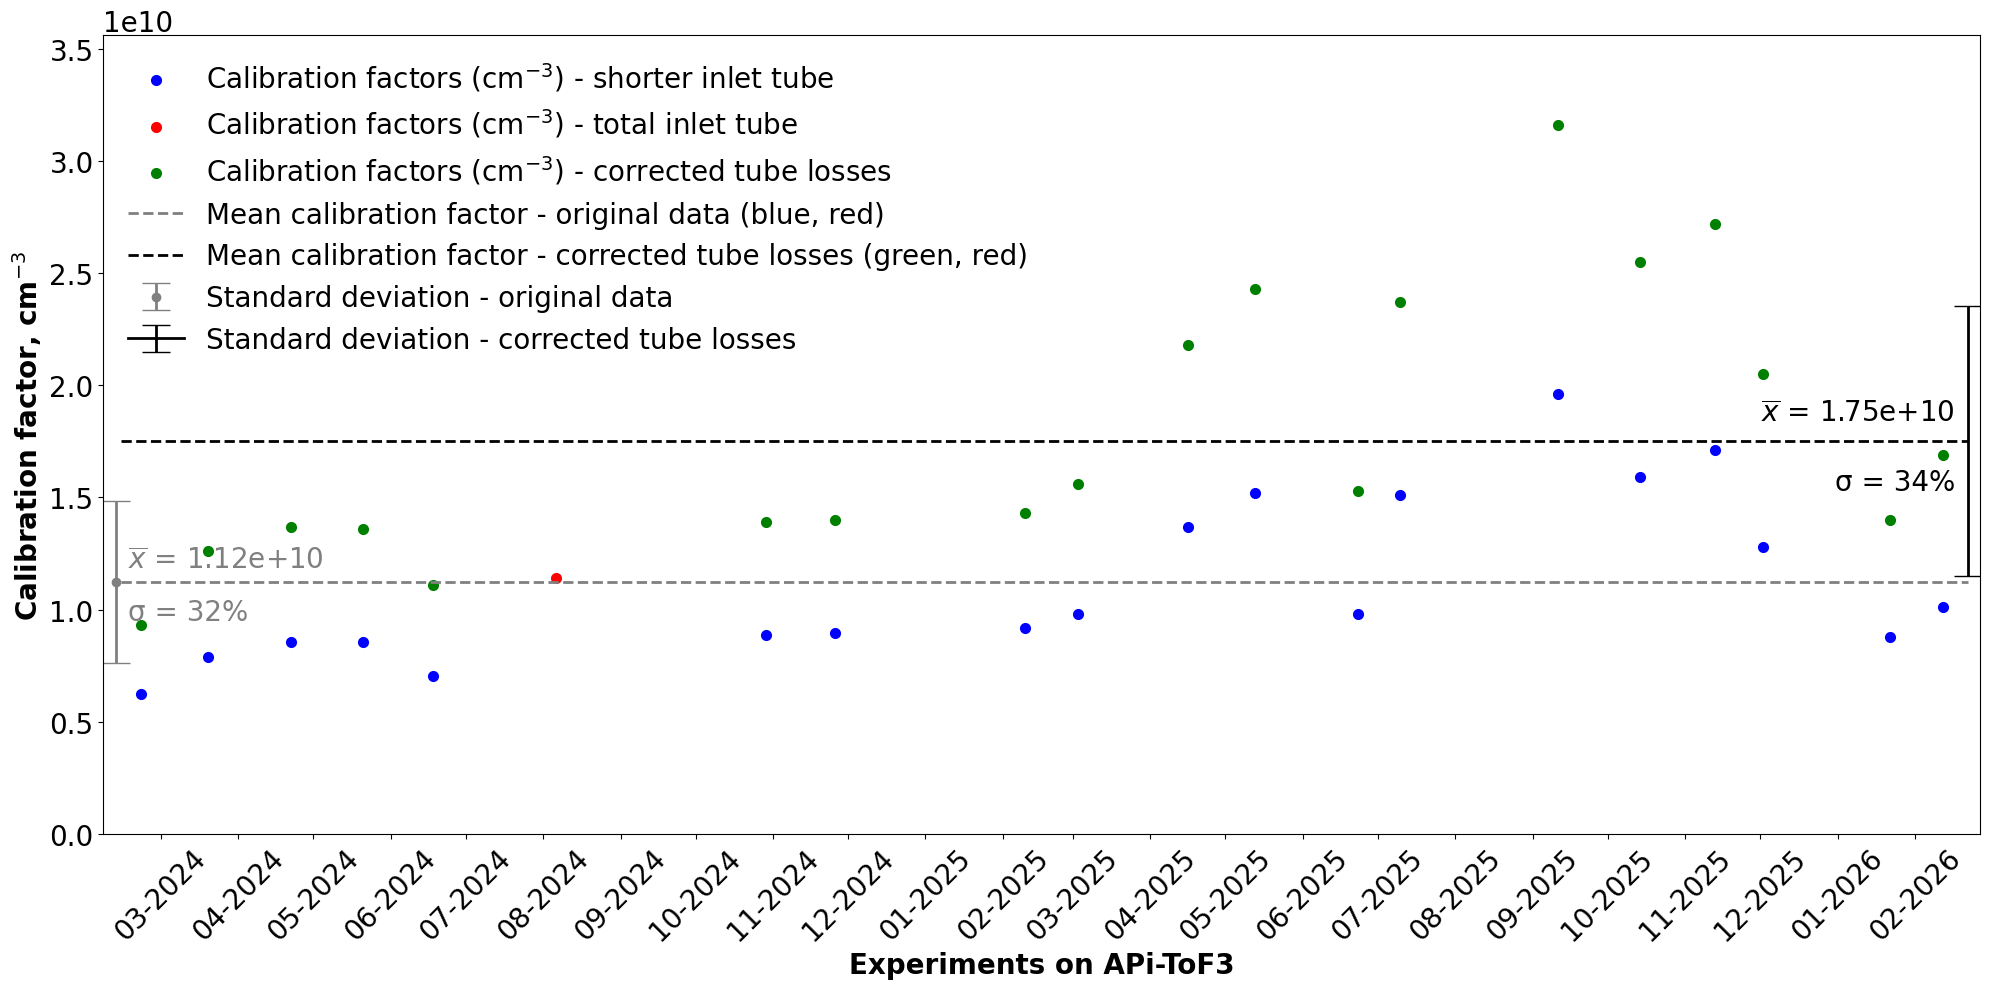

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# Data - original
x = [datetime(2024, 2, 22), datetime(2024, 3, 20), datetime(2024, 4, 22),
     datetime(2024, 5, 21), datetime(2024, 6, 18), datetime(2024, 10, 29), 
     datetime(2024, 11, 26), datetime(2025, 2, 10), datetime(2025, 3, 3), 
     datetime(2025, 4, 16), datetime(2025, 5, 13), datetime(2025, 6, 23),
    datetime(2025, 7, 10), datetime(2025, 9, 11), datetime(2025, 10, 14),
    datetime(2025, 11, 13), datetime(2025, 12, 2), datetime(2026, 1, 22),
    datetime(2026, 2, 12)]
y = np.array([6.26e9, 7.88e9, 8.54e9, 8.54e9, 7.04e9, 8.87e9, 8.96e9, 9.19e9, 
              9.81e9, 1.37e10, 1.52e10, 9.80e9, 1.51e10, 1.96e10, 1.59e10,
              1.71e10, 1.28e10, 8.77e9, 1.01e10])

# Additional point - total inlet tube
x_new = [datetime(2024, 8, 6)]
y_new = np.array([1.14e10])

# Data - corrected tube losses
x_corrected =  [datetime(2024, 2, 22), datetime(2024, 3, 20), datetime(2024, 4, 22),
                datetime(2024, 5, 21), datetime(2024, 6, 18), datetime(2024, 10, 29), 
                datetime(2024, 11, 26), datetime(2025, 2, 10), datetime(2025, 3, 3), 
                datetime(2025, 4, 16), datetime(2025, 5, 13), datetime(2025, 6, 23),
                datetime(2025, 7, 10), datetime(2025, 9, 11), datetime(2025, 10, 14),
                datetime(2025, 11, 13), datetime(2025, 12, 2), datetime(2026, 1, 22),
                datetime(2026, 2, 12)]
y_corrected = np.array([9.32e9, 1.26e10, 1.37e10, 1.36e10, 1.11e10, 1.39e10, 1.40e10, 1.43e10, 
                        1.56e10, 2.18e10, 2.43e10, 1.53e10, 2.37e10, 3.16e10, 2.55e10,
                        2.72e10, 2.05e10, 1.40e10, 1.69e10])

# Calculate mean and standard deviation for original data
mean_y = np.mean(y)
std_y = np.std(y)
std_percentage = int((std_y / mean_y) * 100)  

# Calculate mean and standard deviation for original data + additional point
all_y = np.concatenate((y, y_new))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  

# Calculate mean and standard deviation for corrected data
corrected_y = np.concatenate((y_corrected, y_new))
mean_corrected_y = np.mean(corrected_y)
std_corrected_y = np.std(corrected_y)
std_corrected_percentage = int((std_corrected_y / mean_corrected_y) * 100) 

# Create plot
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(x, y, color='blue', linewidth=2, label='Calibration factors (cm$^{-3}$) - shorter inlet tube')
ax.scatter(x_new, y_new, color='red', linewidth=2, label='Calibration factors (cm$^{-3}$) - total inlet tube')
ax.scatter(x_corrected, y_corrected, color='green', linewidth=2, label='Calibration factors (cm$^{-3}$) - corrected tube losses')

# Customize plot
ax.set_xlabel('Experiments on APi-ToF3', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x + x_new) - timedelta(days=15), max(x + x_new) + timedelta(days=15)])
ax.set_ylim([0, max(y_corrected) + 4e9])
ax.tick_params(axis='y', labelsize=20) 
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)
plt.tight_layout()

# Plot statistics
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_all_y, mean_all_y], '--', color='grey', linewidth=2, label='Mean calibration factor - original data (blue, red)')
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_corrected_y, mean_corrected_y], 'k--', linewidth=2, label='Mean calibration factor - corrected tube losses (green, red)')
ax.errorbar(min(x + x_new) - timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='o', color='grey', linewidth=2, capsize=10, label='Standard deviation - original data')
ax.errorbar(max(x + x_new) + timedelta(days=10), mean_corrected_y, yerr=std_corrected_y, fmt='k', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='grey')
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='left', fontsize=20, color='grey')
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y + std_corrected_y * 0.1, f'$\overline{{x}}$ = {mean_corrected_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='black')
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y - std_corrected_y * 0.2, f'σ = {std_corrected_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='black')

# Legend 
ax.legend(loc='upper left', framealpha=0, fontsize=20)  # Make legend background transparent

# Show the plot
plt.show()

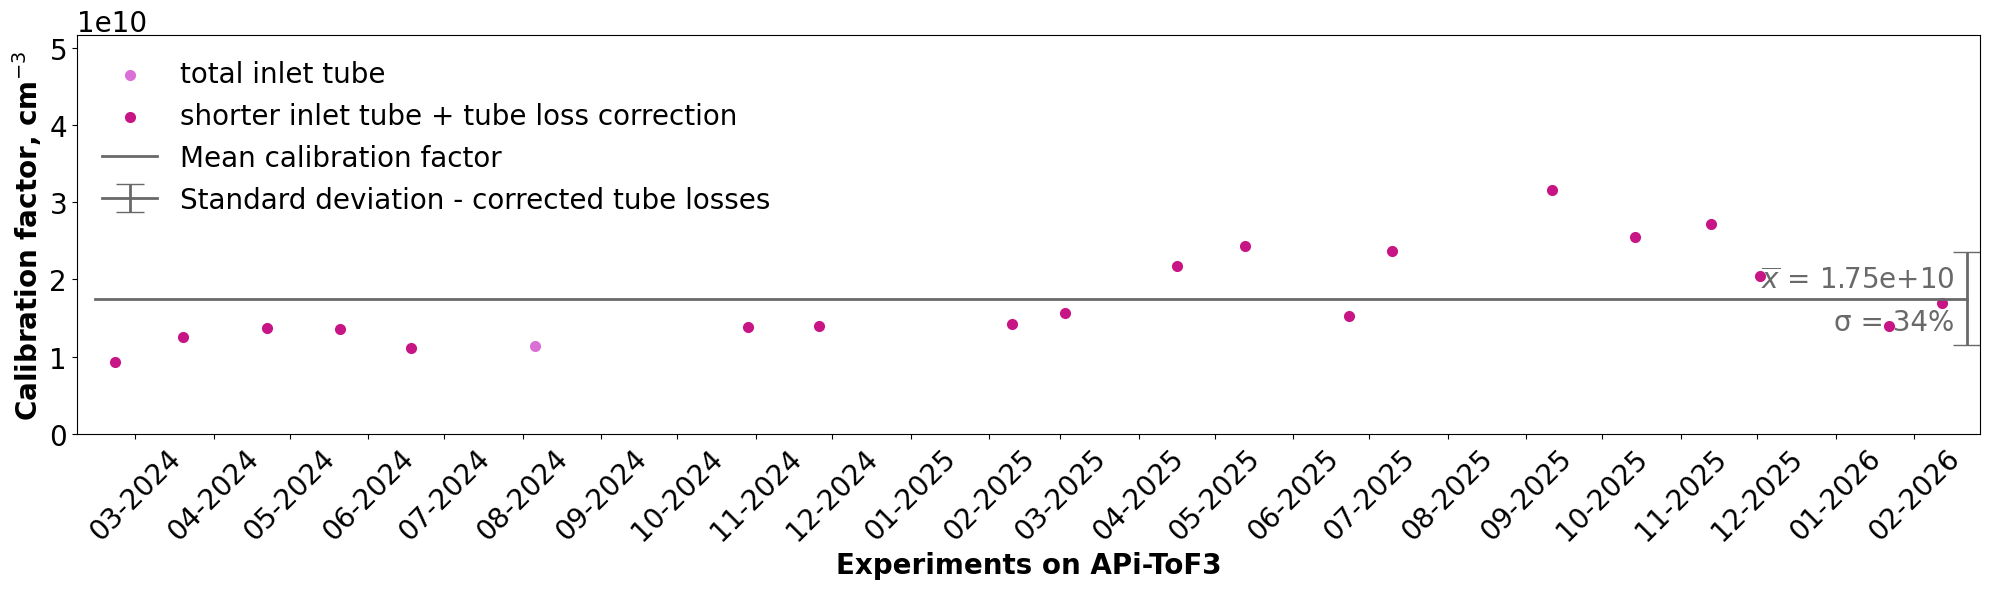

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

x_corrected =  [datetime(2024, 2, 22), datetime(2024, 3, 20), datetime(2024, 4, 22), datetime(2024, 5, 21), datetime(2024, 6, 18), datetime(2024, 10, 29), 
                datetime(2024, 11, 26), datetime(2025, 2, 10), datetime(2025, 3, 3), datetime(2025, 4, 16), datetime(2025, 5, 13), datetime(2025, 6, 23),
                datetime(2025, 7, 10), datetime(2025, 9, 11), datetime(2025, 10, 14), datetime(2025, 11, 13), datetime(2025, 12, 2), datetime(2026, 1, 22),
                datetime(2026, 2, 12)]
y_corrected = np.array([9.32e9, 1.26e10, 1.37e10, 1.36e10, 1.11e10, 1.39e10, 1.40e10, 1.43e10, 1.56e10, 2.18e10, 2.43e10, 1.53e10, 2.37e10, 3.16e10, 2.55e10,
                        2.72e10, 2.05e10, 1.40e10, 1.69e10])

x_campaign = [datetime(2024, 8, 6)]
y_campaign = np.array([1.14e10])

all_y = np.concatenate((y_corrected, y_campaign))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  

fig, ax = plt.subplots(figsize=(20, 6))
ax.scatter(x_campaign, y_campaign, color='orchid', linewidth=2, label='total inlet tube')
ax.scatter(x_corrected, y_corrected, color='mediumvioletred', linewidth=2, label='shorter inlet tube + tube loss correction')

ax.set_xlabel('Experiments on APi-ToF3', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x_corrected + x_campaign) - timedelta(days=15), max(x_corrected + x_campaign) + timedelta(days=15)])
ax.set_ylim([0, max(y_corrected) + 2e10])
ax.tick_params(axis='y', labelsize=20) 
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)

ax.plot([min(x_corrected + x_campaign) - timedelta(days=8), max(x_corrected + x_campaign) + timedelta(days=10)], [mean_all_y, mean_all_y], 'dimgray', linewidth=2, label='Mean calibration factor')
ax.errorbar(max(x_corrected + x_campaign) + timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='dimgray', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='dimgray')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='dimgray')
 
ax.legend(loc='upper left', framealpha=0, fontsize=20)  

fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

### APi-ToF12 - nitrate mode

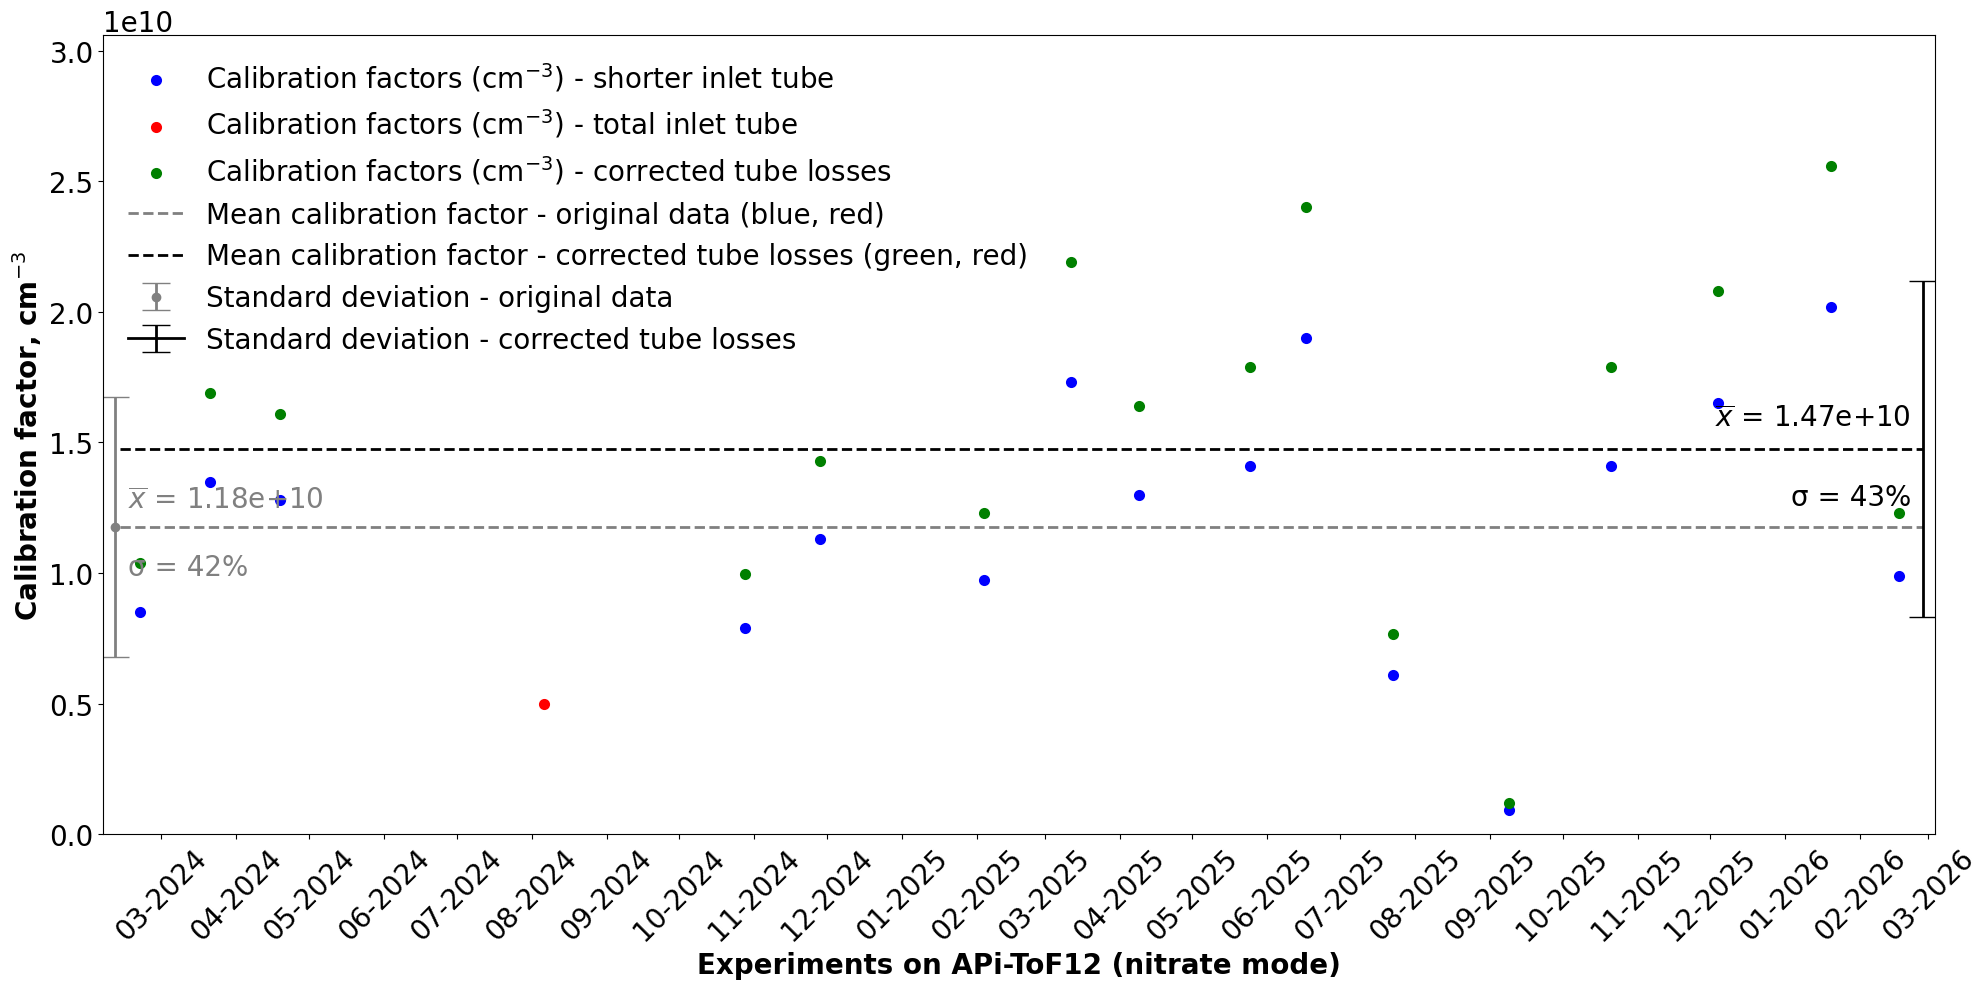

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# Data
x = [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 4, 19), datetime(2024, 10, 28),
    datetime(2024, 11, 28), datetime(2025, 2, 4), datetime(2025, 3, 12), datetime(2025, 4, 9),
    datetime(2025, 5, 25), datetime(2025, 6, 17), datetime(2025, 7, 23), datetime(2025, 9, 9), 
    datetime(2025, 10, 21), datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y = np.array([8.50e9, 1.35e10, 1.28e10, 7.88e9, 1.13e10, 9.74e9, 1.73e10, 1.30e10, 1.41e10, 1.90e10, 
              6.09e9, 9.22e8, 1.41e10, 1.65e10, 2.02e10, 9.90e9])

# Additional point - total inlet tube
x_new = [datetime(2024, 8, 6)]
y_new = np.array([4.98e9])

# Data - corrected tube losses
x_corrected = [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 4, 19), datetime(2024, 10, 28),
    datetime(2024, 11, 28), datetime(2025, 2, 4), datetime(2025, 3, 12), datetime(2025, 4, 9),
    datetime(2025, 5, 25), datetime(2025, 6, 17), datetime(2025, 7, 23), datetime(2025, 9, 9), 
    datetime(2025, 10, 21), datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y_corrected = np.array([1.04e10, 1.69e10, 1.61e10, 9.95e9, 1.43e10, 1.23e10, 2.19e10, 1.64e10, 1.79e10, 2.40e10, 
                        7.65e9, 1.18e9, 1.79e10, 2.08e10, 2.56e10, 1.23e10])

# Calculate mean and standard deviation for original data
mean_y = np.mean(y)
std_y = np.std(y)
std_percentage = int((std_y / mean_y) * 100)  # No decimals displayed

# Calculate mean and standard deviation for original data + additional point
all_y = np.concatenate((y, y_new))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  # No decimals displayed

# Calculate mean and standard deviation for corrected data
corrected_y = np.concatenate((y_corrected, y_new))
mean_corrected_y = np.mean(corrected_y)
std_corrected_y = np.std(corrected_y)
std_corrected_percentage = int((std_corrected_y / mean_corrected_y) * 100)  # No decimals displayed

# Create the plot
fig, ax = plt.subplots(figsize=(20, 10))

# Scatter plot
ax.scatter(x, y, color='blue', linewidth=2, label='Calibration factors (cm$^{-3}$) - shorter inlet tube')
ax.scatter(x_new, y_new, color='red', linewidth=2, label='Calibration factors (cm$^{-3}$) - total inlet tube')
ax.scatter(x_corrected, y_corrected, color='green', linewidth=2, label='Calibration factors (cm$^{-3}$) - corrected tube losses')

# Labels and limits
ax.set_xlabel('Experiments on APi-ToF12 (nitrate mode)', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x + x_new) - timedelta(days=15), max(x + x_new) + timedelta(days=15)])
ax.set_ylim([0, max(y_corrected) + 5e9])

# Adjust font size of y-axis tick labels
ax.tick_params(axis='y', labelsize=20)  # Change y-axis tick label size

# Format scientific notation for y-axis
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20)  # Set fontsize for scientific notation

# Plot mean line for original data
#ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_y, mean_y], 'k--', linewidth=2, label='Mean calibration factor - shorter inlet tube')

# Plot mean line for original data + additional point (lighter grey)
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_all_y, mean_all_y], '--', color='grey', linewidth=2, label='Mean calibration factor - original data (blue, red)')

# Plot mean line for corrected data 
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_corrected_y, mean_corrected_y], 'k--', linewidth=2, label='Mean calibration factor - corrected tube losses (green, red)')

# Plot error bar for original data standard deviation
#ax.errorbar(max(x + x_new) + timedelta(days=10), mean_y, yerr=std_y, fmt='k', linewidth=2, capsize=10, label='Standard deviation - shorter inlet tube')

# Plot error bar for original data + additional point standard deviation (lighter grey) on the left
ax.errorbar(min(x + x_new) - timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='o', color='grey', linewidth=2, capsize=10, label='Standard deviation - original data')

# Plot error bar for corrected data standard deviation
ax.errorbar(max(x + x_new) + timedelta(days=10), mean_corrected_y, yerr=std_corrected_y, fmt='k', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')


# Add text for original tube mean and standard deviation (on the right)
#ax.text(max(x + x_new) + timedelta(days=5), mean_y + std_y * 0.1, f'$\overline{{x}}$ = {mean_y:.2e}', 
#        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='black')
#ax.text(max(x + x_new) + timedelta(days=5), mean_y - std_y * 0.2, f'σ = {std_percentage}%', 
#        verticalalignment='top', horizontalalignment='right', fontsize=20, color='black')

# Add text for original data + additional point mean and standard deviation (on the left)
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='grey')
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='left', fontsize=20, color='grey')

# Add text for corrected mean and standard deviation (on the right)
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y + std_corrected_y * 0.1, f'$\overline{{x}}$ = {mean_corrected_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='black')
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y - std_corrected_y * 0.2, f'σ = {std_corrected_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='black')

# Legend with transparent background
ax.legend(loc='upper left', framealpha=0, fontsize=20)  # Make legend background transparent
    
# Set the date format on the x-axis to month and year only
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)

# Use tight_layout before saving to ensure proper spacing
plt.tight_layout()

# Save the figure with transparent background
#plt.savefig(r'C:\Users\ceciliar\OneDrive - University of Helsinki\Desktop\APi3_calibration_factor.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

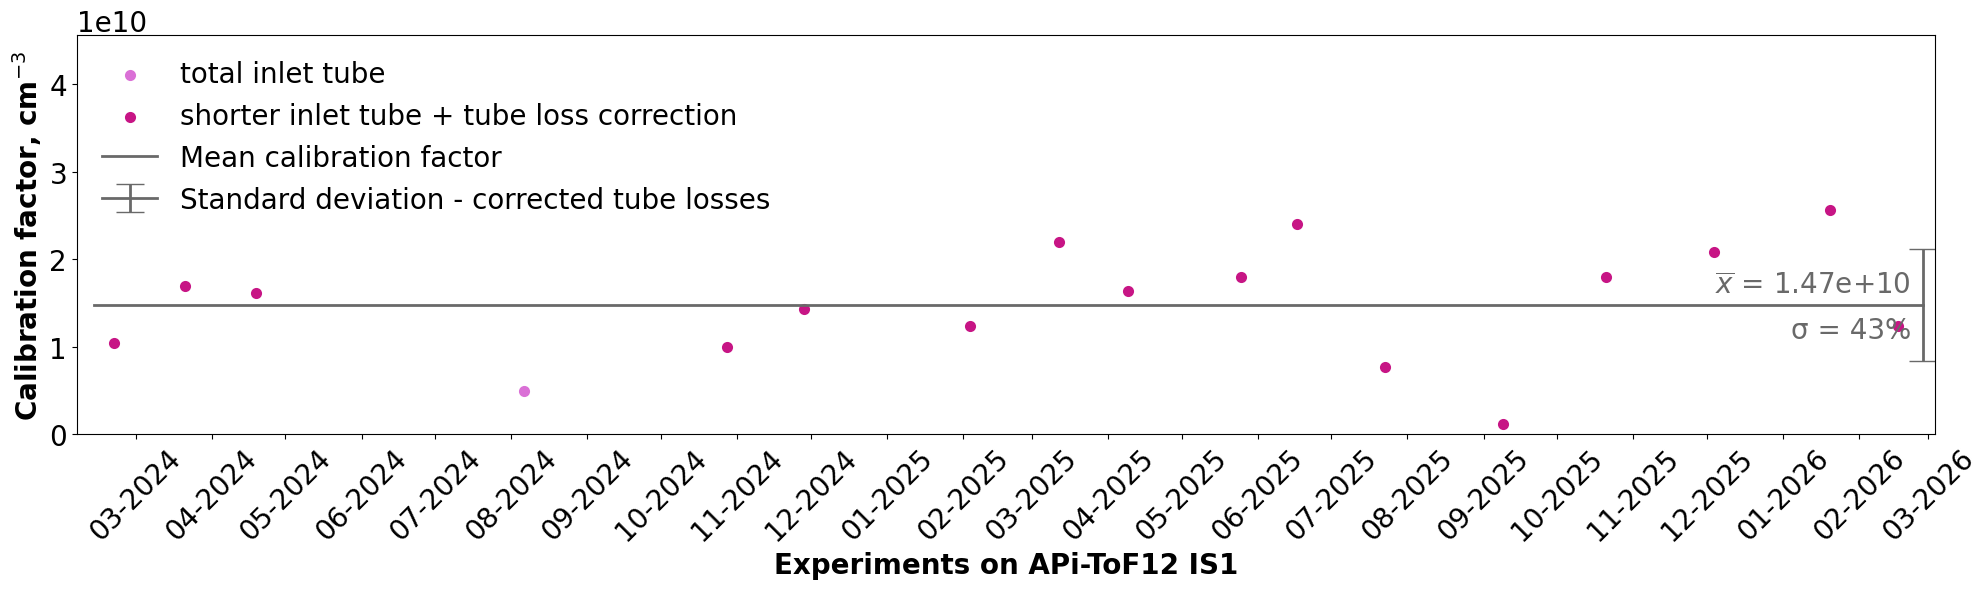

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

x_corrected =  [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 4, 19), datetime(2024, 10, 28), datetime(2024, 11, 28), datetime(2025, 2, 4), datetime(2025, 3, 12), datetime(2025, 4, 9),
                datetime(2025, 5, 25), datetime(2025, 6, 17), datetime(2025, 7, 23), datetime(2025, 9, 9), datetime(2025, 10, 21), datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y_corrected = np.array([1.04e10, 1.69e10, 1.61e10, 9.95e9, 1.43e10, 1.23e10, 2.19e10, 1.64e10, 1.79e10, 2.40e10, 7.66e9, 1.18e9, 1.80e10, 2.08e10, 2.56e10, 1.23e10])

x_campaign = [datetime(2024, 8, 6)]
y_campaign = np.array([4.98e9])

all_y = np.concatenate((y_corrected, y_campaign))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  

fig, ax = plt.subplots(figsize=(20, 6))
ax.scatter(x_campaign, y_campaign, color='orchid', linewidth=2, label='total inlet tube')
ax.scatter(x_corrected, y_corrected, color='mediumvioletred', linewidth=2, label='shorter inlet tube + tube loss correction')

ax.set_xlabel('Experiments on APi-ToF12 IS1', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x_corrected + x_campaign) - timedelta(days=15), max(x_corrected + x_campaign) + timedelta(days=15)])
ax.set_ylim([0, max(y_corrected) + 2e10])
ax.tick_params(axis='y', labelsize=20) 
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)

ax.plot([min(x_corrected + x_campaign) - timedelta(days=8), max(x_corrected + x_campaign) + timedelta(days=10)], [mean_all_y, mean_all_y], 'dimgray', linewidth=2, label='Mean calibration factor')
ax.errorbar(max(x_corrected + x_campaign) + timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='dimgray', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='dimgray')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='dimgray')
 
ax.legend(loc='upper left', framealpha=0, fontsize=20)  

fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

### APi-ToF12 - bromine mode

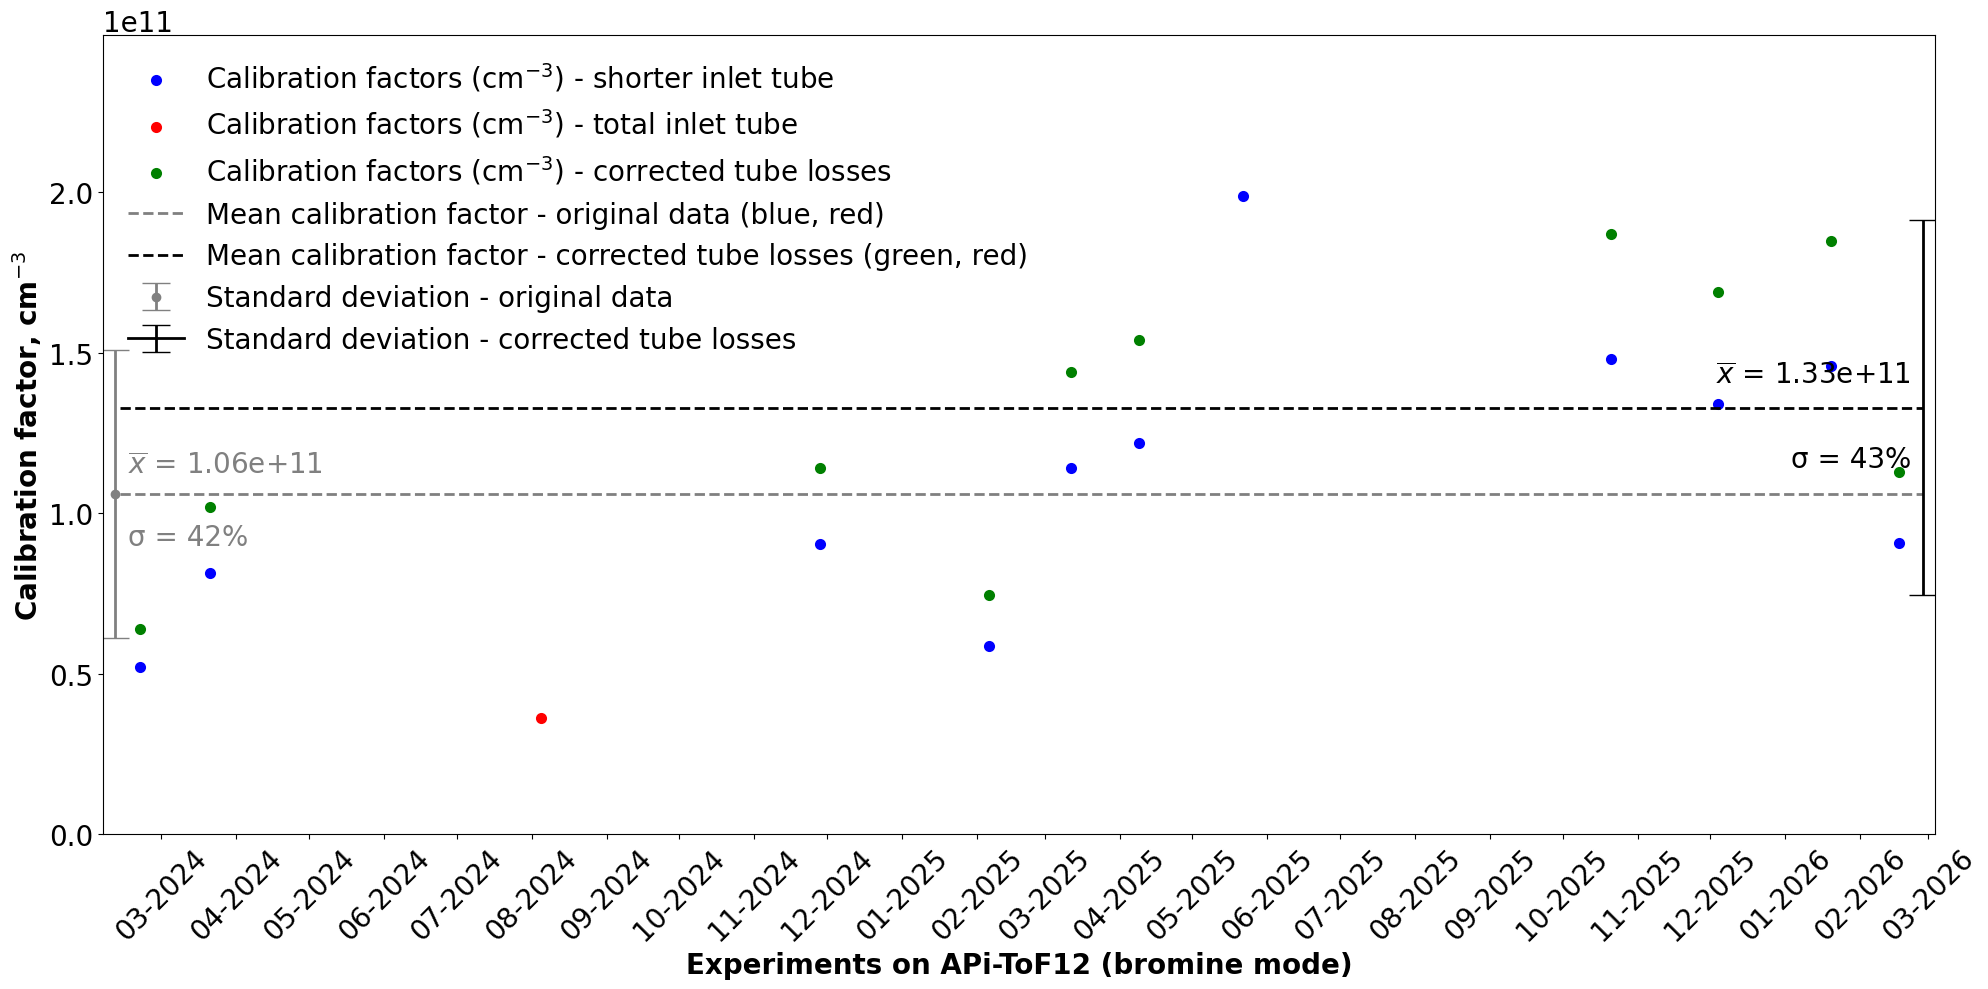

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# Data - original
x = [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 11, 28), datetime(2025, 2, 6), 
     datetime(2025, 3, 12), datetime(2025, 4, 9), datetime(2025, 5, 22), datetime(2025, 10, 21), 
     datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y = np.array([5.22e10, 8.14e10, 9.03e10, 5.85e10, 1.14e11, 1.22e11, 1.99e11, 1.48e11, 
              1.34e11, 1.46e11, 9.08e10])

# Additional point - total inlet tube
x_new = [datetime(2024, 8, 5)]
y_new = np.array([3.61e10])

# Data - corrected tube losses
x_corrected =   [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 11, 28), datetime(2025, 2, 6), 
                 datetime(2025, 3, 12), datetime(2025, 4, 9), datetime(2025, 5, 22), datetime(2025, 10, 21), 
                 datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y_corrected = np.array([6.40e10, 1.02e11, 1.14e11, 7.44e10, 1.44e11, 1.54e11, 2.52e11, 1.87e11, 
                        1.69e11, 1.85e11, 1.13e11])

# Calculate mean and standard deviation for original data
mean_y = np.mean(y)
std_y = np.std(y)
std_percentage = int((std_y / mean_y) * 100)  # No decimals displayed

# Calculate mean and standard deviation for original data + additional point
all_y = np.concatenate((y, y_new))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  # No decimals displayed

# Calculate mean and standard deviation for corrected data
corrected_y = np.concatenate((y_corrected, y_new))
mean_corrected_y = np.mean(corrected_y)
std_corrected_y = np.std(corrected_y)
std_corrected_percentage = int((std_corrected_y / mean_corrected_y) * 100)  # No decimals displayed

# Create the plot
fig, ax = plt.subplots(figsize=(20, 10))

# Scatter plot
ax.scatter(x, y, color='blue', linewidth=2, label='Calibration factors (cm$^{-3}$) - shorter inlet tube')
ax.scatter(x_new, y_new, color='red', linewidth=2, label='Calibration factors (cm$^{-3}$) - total inlet tube')
ax.scatter(x_corrected, y_corrected, color='green', linewidth=2, label='Calibration factors (cm$^{-3}$) - corrected tube losses')

# Labels and limits
ax.set_xlabel('Experiments on APi-ToF12 (bromine mode)', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x + x_new) - timedelta(days=15), max(x + x_new) + timedelta(days=15)])
ax.set_ylim([0, max(y) + 5e10])

# Adjust font size of y-axis tick labels
ax.tick_params(axis='y', labelsize=20)  # Change y-axis tick label size

# Format scientific notation for y-axis
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20)  # Set fontsize for scientific notation

# Plot mean line for original data
#ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_y, mean_y], 'k--', linewidth=2, label='Mean calibration factor - shorter inlet tube')

# Plot mean line for original data + additional point (lighter grey)
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_all_y, mean_all_y], '--', color='grey', linewidth=2, label='Mean calibration factor - original data (blue, red)')

# Plot mean line for corrected data 
ax.plot([min(x + x_new) - timedelta(days=8), max(x + x_new) + timedelta(days=10)], [mean_corrected_y, mean_corrected_y], 'k--', linewidth=2, label='Mean calibration factor - corrected tube losses (green, red)')

# Plot error bar for original data standard deviation
#ax.errorbar(max(x + x_new) + timedelta(days=10), mean_y, yerr=std_y, fmt='k', linewidth=2, capsize=10, label='Standard deviation - shorter inlet tube')

# Plot error bar for original data + additional point standard deviation (lighter grey) on the left
ax.errorbar(min(x + x_new) - timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='o', color='grey', linewidth=2, capsize=10, label='Standard deviation - original data')

# Plot error bar for corrected data standard deviation
ax.errorbar(max(x + x_new) + timedelta(days=10), mean_corrected_y, yerr=std_corrected_y, fmt='k', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')


# Add text for original tube mean and standard deviation (on the right)
#ax.text(max(x + x_new) + timedelta(days=5), mean_y + std_y * 0.1, f'$\overline{{x}}$ = {mean_y:.2e}', 
#        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='black')
#ax.text(max(x + x_new) + timedelta(days=5), mean_y - std_y * 0.2, f'σ = {std_percentage}%', 
#        verticalalignment='top', horizontalalignment='right', fontsize=20, color='black')

# Add text for original data + additional point mean and standard deviation (on the left)
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='left', fontsize=20, color='grey')
ax.text(min(x + x_new) - timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='left', fontsize=20, color='grey')

# Add text for corrected mean and standard deviation (on the right)
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y + std_corrected_y * 0.1, f'$\overline{{x}}$ = {mean_corrected_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='black')
ax.text(max(x + x_new) + timedelta(days=5), mean_corrected_y - std_corrected_y * 0.2, f'σ = {std_corrected_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='black')

# Legend with transparent background
ax.legend(loc='upper left', framealpha=0, fontsize=20)  # Make legend background transparent
    
# Set the date format on the x-axis to month and year only
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)

# Use tight_layout before saving to ensure proper spacing
plt.tight_layout()

# Save the figure with transparent background
#plt.savefig(r'C:\Users\ceciliar\OneDrive - University of Helsinki\Desktop\APi3_calibration_factor.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

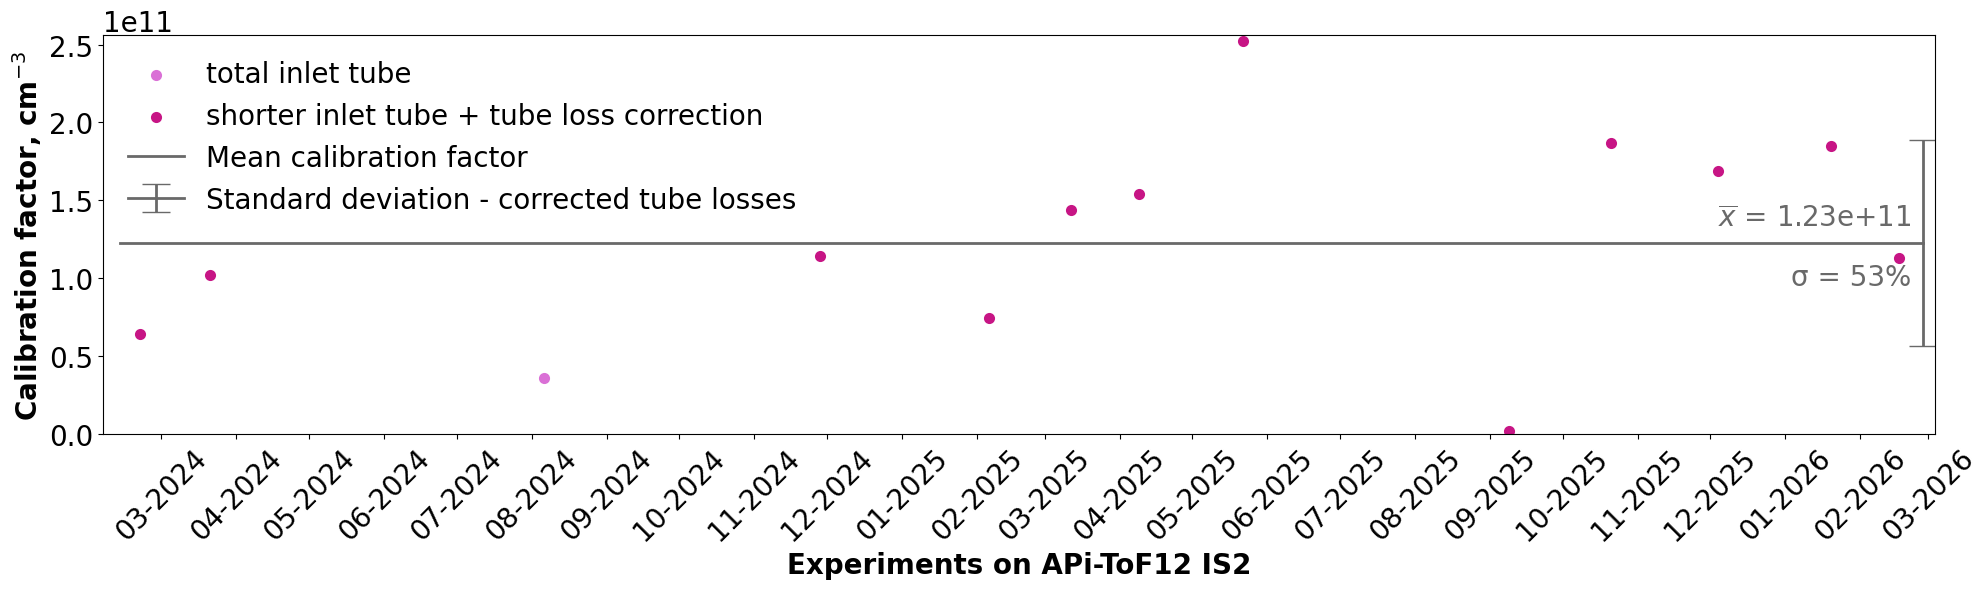

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

x_corrected =  [datetime(2024, 2, 21), datetime(2024, 3, 21), datetime(2024, 11, 28), datetime(2025, 2, 6), datetime(2025, 3, 12), datetime(2025, 4, 9), datetime(2025, 5, 22), 
                datetime(2025, 9, 9), datetime(2025, 10, 21), datetime(2025, 12, 4), datetime(2026, 1, 20), datetime(2026, 2, 17)]
y_corrected = np.array([6.40e10, 1.02e11, 1.14e11, 7.44e10, 1.44e11, 1.54e11, 2.52e11, 2.11e9, 1.87e11, 1.69e11, 1.85e11, 1.13e11])

x_campaign = [datetime(2024, 8, 6)]
y_campaign = np.array([3.61e10])

all_y = np.concatenate((y_corrected, y_campaign))
mean_all_y = np.mean(all_y)
std_all_y = np.std(all_y)
std_all_percentage = int((std_all_y / mean_all_y) * 100)  

fig, ax = plt.subplots(figsize=(20, 6))
ax.scatter(x_campaign, y_campaign, color='orchid', linewidth=2, label='total inlet tube')
ax.scatter(x_corrected, y_corrected, color='mediumvioletred', linewidth=2, label='shorter inlet tube + tube loss correction')

ax.set_xlabel('Experiments on APi-ToF12 IS2', fontweight='bold', fontsize=20)
ax.set_ylabel(r'Calibration factor, cm$^{-3}$', fontweight='bold', fontsize=20)  
ax.set_xlim([min(x_corrected + x_campaign) - timedelta(days=15), max(x_corrected + x_campaign) + timedelta(days=15)])
ax.set_ylim([0, max(y_corrected) + 4e9])
ax.tick_params(axis='y', labelsize=20) 
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be every month
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=20)

ax.plot([min(x_corrected + x_campaign) - timedelta(days=8), max(x_corrected + x_campaign) + timedelta(days=10)], [mean_all_y, mean_all_y], 'dimgray', linewidth=2, label='Mean calibration factor')
ax.errorbar(max(x_corrected + x_campaign) + timedelta(days=10), mean_all_y, yerr=std_all_y, fmt='dimgray', linewidth=2, capsize=10, label='Standard deviation - corrected tube losses')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y + std_all_y * 0.1, f'$\overline{{x}}$ = {mean_all_y:.2e}', 
        verticalalignment='bottom', horizontalalignment='right', fontsize=20, color='dimgray')
ax.text(max(x_corrected + x_campaign) + timedelta(days=5), mean_all_y - std_all_y * 0.2, f'σ = {std_all_percentage}%', 
        verticalalignment='top', horizontalalignment='right', fontsize=20, color='dimgray')
 
ax.legend(loc='upper left', framealpha=0, fontsize=20)  

plt.tight_layout()
plt.show()

## Relative Humidity during SA calibration

### APi-ToF3

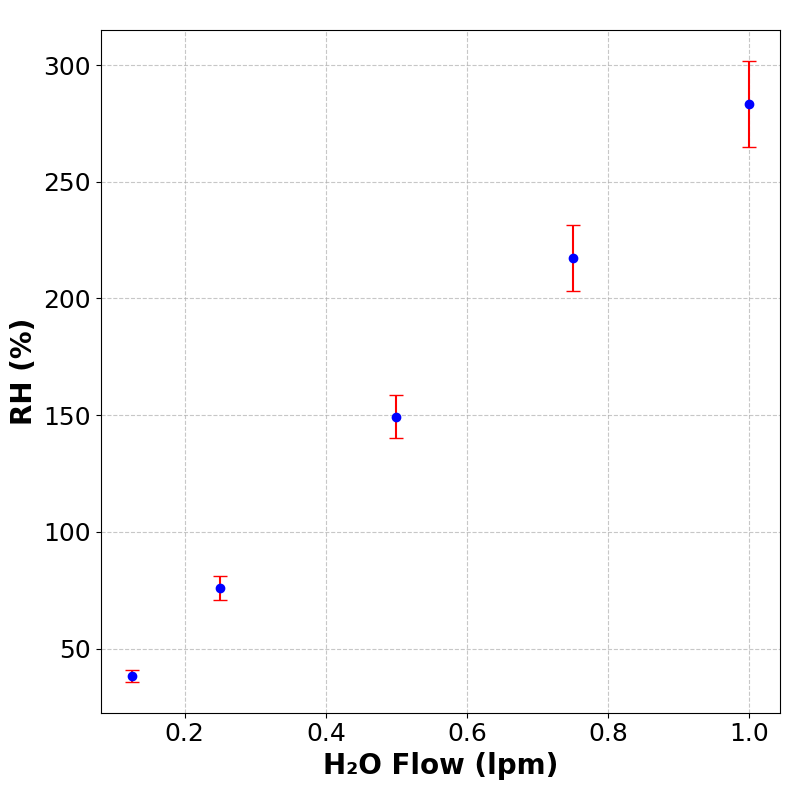

In [3]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Concentration steps
concentration_steps = [0.125, 0.250, 0.500, 0.750, 1.000]  # H₂0 flow

# RH measurements for each concentration step
rh_measurements = [
    [35, 34, 40, 39, 39, 33, 35, 41, 38, 41, 40, 42, 39, 37, 38, 38, 41, 38, 37, 38, 43],    # Measurements for step 1
    [69, 68, 80, 77, 77, 65, 69, 81, 76, 82, 79, 83, 77, 74, 74, 75, 80, 75, 74, 76, 84],    # Measurements for step 2
    [135, 133, 156, 150, 151, 128, 155, 158, 148, 160, 154, 163, 150, 144, 145, 146, 156, 147, 144, 148, 164],    # Measurements for step 3
    [197, 195, 228, 219, 221, 187, 197, 232, 216, 234, 225, 238, 219, 211, 213, 215, 229, 216, 212, 217, 241],    # Measurements for step 4
    [257, 254, 298, 286, 289, 244, 257, 303, 282, 305, 293, 310, 286, 275, 277, 280, 299, 282, 276, 283, 313]     # Measurements for step 5
]

# Calculate average RH and standard deviation for each step
average_rh = [np.mean(measurements) for measurements in rh_measurements]
std_dev_rh = [np.std(measurements) for measurements in rh_measurements]

# Create plot
plt.figure(figsize=(8, 8))
plt.errorbar(concentration_steps, average_rh, yerr=std_dev_rh, fmt='o',
             color='blue', ecolor='red', elinewidth=1.5, capsize=5, label='RH with Std Dev')

# Customize plot
plt.title(' ')
plt.xlabel('H₂O Flow (lpm)', fontsize=20, fontweight='bold')
plt.ylabel('RH (%)', fontsize=20, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.tight_layout()

# Show the plot
plt.show()

### APi-ToF12

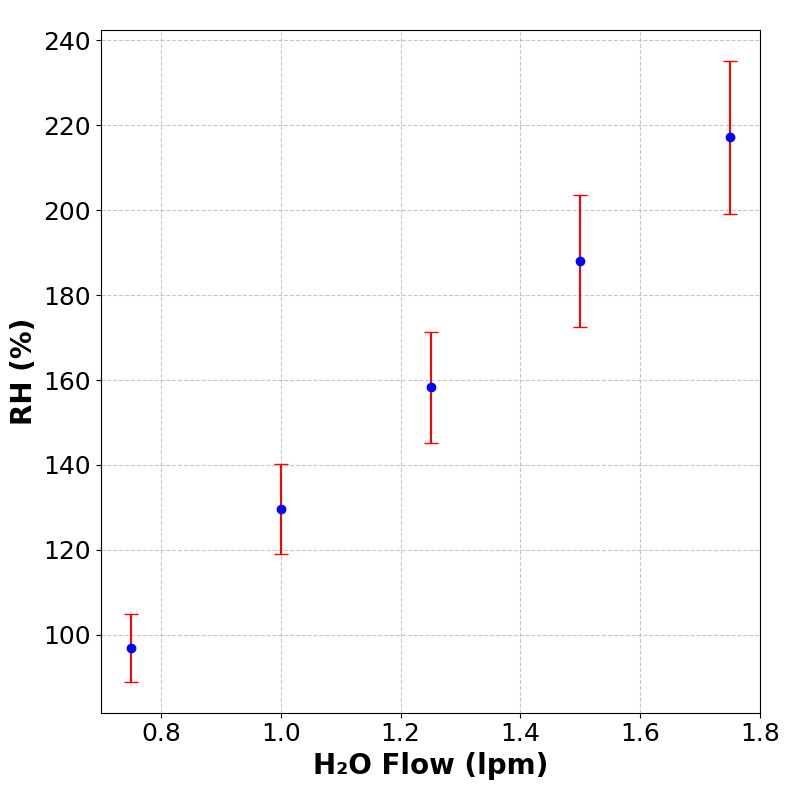

In [5]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Concentration steps
concentration_steps = [0.750, 1.000, 1.250, 1.500, 1.750]  # H₂0 flow

# RH measurements for each concentration step
rh_measurements = [
    [115, 107, 103, 90, 89, 96, 93, 94, 89, 87, 95, 95, 93, 112, 92, 89, 107, 99, 97],    # Measurements for step 1
    [152, 141, 135, 119, 117, 126, 123, 125, 118, 144, 125, 126, 123, 148, 121, 118, 142, 131, 129],    # Measurements for step 2
    [188, 174, 168, 147, 145, 156, 152, 154, 146, 141, 155, 156, 152, 183, 150, 145, 175, 162, 159],    # Measurements for step 3
    [224, 207, 199, 174, 172, 185, 180, 183, 173, 168, 184, 185, 181, 217, 178, 173, 208, 192, 189],    # Measurements for step 4
    [258, 239, 230, 201, 199, 214, 208, 211, 200, 194, 212, 214, 209, 251, 205, 200, 240, 222, 218]     # Measurements for step 5
]

# Calculate average RH and standard deviation for each step
average_rh = [np.mean(measurements) for measurements in rh_measurements]
std_dev_rh = [np.std(measurements) for measurements in rh_measurements]

# Create plot
plt.figure(figsize=(8, 8))
plt.errorbar(concentration_steps, average_rh, yerr=std_dev_rh, fmt='o',
             color='blue', ecolor='red', elinewidth=1.5, capsize=5, label='RH with Std Dev')

# Customize plot
plt.title(' ')
plt.xlabel('H₂O Flow (lpm)', fontsize=20, fontweight='bold')
plt.ylabel('RH (%)', fontsize=20, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.tight_layout()

# Show the plot
plt.show()

## Standard deviation in single steps

### APi-ToF3

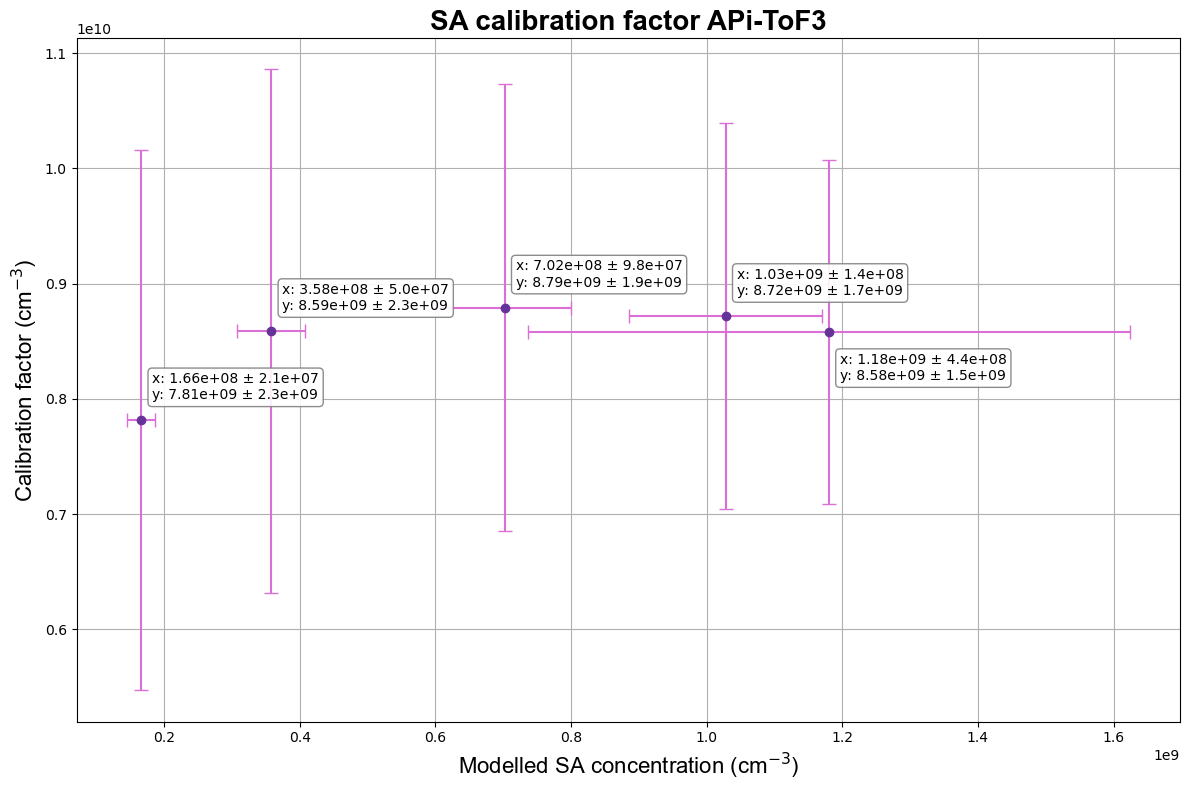

In [40]:
import numpy as np
import matplotlib.pyplot as plt

modelled_SA = [
    [1.64e8, 1.64e8, 1.64e8, 1.38e8, 1.38e8, 1.42e8, 1.35e8, 1.87e8, 1.76e8, 1.76e8, 1.82e8, 1.91e8, 2.00e8],   # Step 1
    [3.30e8, 3.30e8, 3.48e8, 3.48e8, 2.98e8, 2.98e8, 3.06e8, 3.06e8, 2.93e8, 2.93e8, 3.74e8, 3.85e8, 3.85e8, 3.98e8, 3.98e8, 4.19e8, 4.19e8, 4.35e8, 4.35e8],    # Step 2
    [6.46e8, 6.46e8, 6.83e8, 6.83e8, 5.84e8, 5.84e8, 6.01e8, 6.01e8, 5.75e8, 5.75e8, 7.35e8, 7.55e8, 7.55e8, 7.82e8, 7.82e8, 8.22e8, 8.22e8, 8.53e8, 8.53e8],   # Step 3
    [9.47e8, 9.47e8, 1.00e9, 1.00e9, 8.56e8, 8.56e8, 8.80e8, 8.80e8, 8.42e8, 8.42e8, 1.08e9, 1.11e9, 1.11e9, 1.14e9, 1.14e9, 1.20e9, 1.20e9, 1.25e9, 1.25e9],    # Step 4
    [1.23e9, 1.23e9, 1.30e9, 1.30e9, 1.11e9, 1.11e9, 1.15e9, 1.15e9, 1.10e9, 1.41e9, 1.44e9, 1.44e9, 1.49e9, 1.49e9, 1.57e7, 1.57e7, 1.63e9, 1.63e9]    # Step 5
]

calibration_factors = [
    [6.19e9, 6.62e9, 8.10e9, 9.24e9, 8.89e9, 8.59e9, 1.43e10, 9.66e9, 5.84e9, 5.50e9, 5.35e9, 6.63e9, 6.68e9],  # Step 1
    [4.14e9, 6.68e9, 8.25e9, 8.43e9, 9.33e9, 9.21e9, 1.00e10, 9.22e9, 3.38e9, 1.40e10, 1.15e10, 7.90e9, 8.18e9, 7.41e9, 7.72e9, 9.41e9, 9.08e9, 9.66e9, 9.69e9],  # Step 2
    [4.95e9, 6.11e9, 8.34e9, 8.34e9, 9.04e9, 8.93e9, 9.44e9, 8.93e9, 3.65e9, 1.04e10, 1.13e10, 8.87e9, 8.81e9, 9.11e9, 8.78e9, 1.02e10, 9.86e9, 1.14e10, 1.06e10],  # Step 3
    [5.84e9, 5.27e9, 8.31e9, 8.18e9, 9.02e9, 8.72e9, 9.30e9, 8.91e9, 4.94e9, 9.22e9, 1.14e10, 8.87e9, 8.80e9, 9.27e9, 8.69e9, 1.00e10, 9.63e9, 1.11e10, 1.02e10],  # Step 4
    [6.35e9, 5.18e9, 8.08e9, 8.19e9, 8.77e9, 8.79e9, 8.81e9, 8.73e9, 5.50e9, 1.08e10, 8.94e9, 8.68e9, 9.14e9, 8.73e9, 9.70e9, 9.52e9, 1.04e10, 1.02e10]  # Step 5
]

x_means = [np.mean(step) for step in modelled_SA]
x_stds = [np.std(step) for step in modelled_SA]

y_means = [np.mean(step) for step in calibration_factors]
y_stds = [np.std(step) for step in calibration_factors]

plt.figure(figsize=(12, 8))
plt.errorbar(x_means, y_means, xerr=x_stds, yerr=y_stds, fmt='o', capsize=5, color='rebeccapurple', ecolor='orchid')
plt.xlabel('Modelled SA concentration (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.ylabel('Calibration factor (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.title('SA calibration factor APi-ToF3', fontweight='bold', fontsize=20, fontname="Arial")
plt.grid(True)

# Define custom offsets for each label (x_offset, y_offset)
offsets = [
    (8, 15),    # Step 1
    (8, 15),   # Step 2
    (8, 15), # Step 3
    (8, 15),  # Step 4
    (8, -35)  # Step 5 
]

for i in range(len(x_means)):
    label = f"x: {x_means[i]:.2e} ± {x_stds[i]:.1e}\n" \
            f"y: {y_means[i]:.2e} ± {y_stds[i]:.1e}"
    plt.annotate(
        label,
        (x_means[i], y_means[i]),
        textcoords="offset points",
        xytext=offsets[i],  
        ha='left',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
    )

plt.tight_layout()
plt.show()

### APi-ToF12 IS1

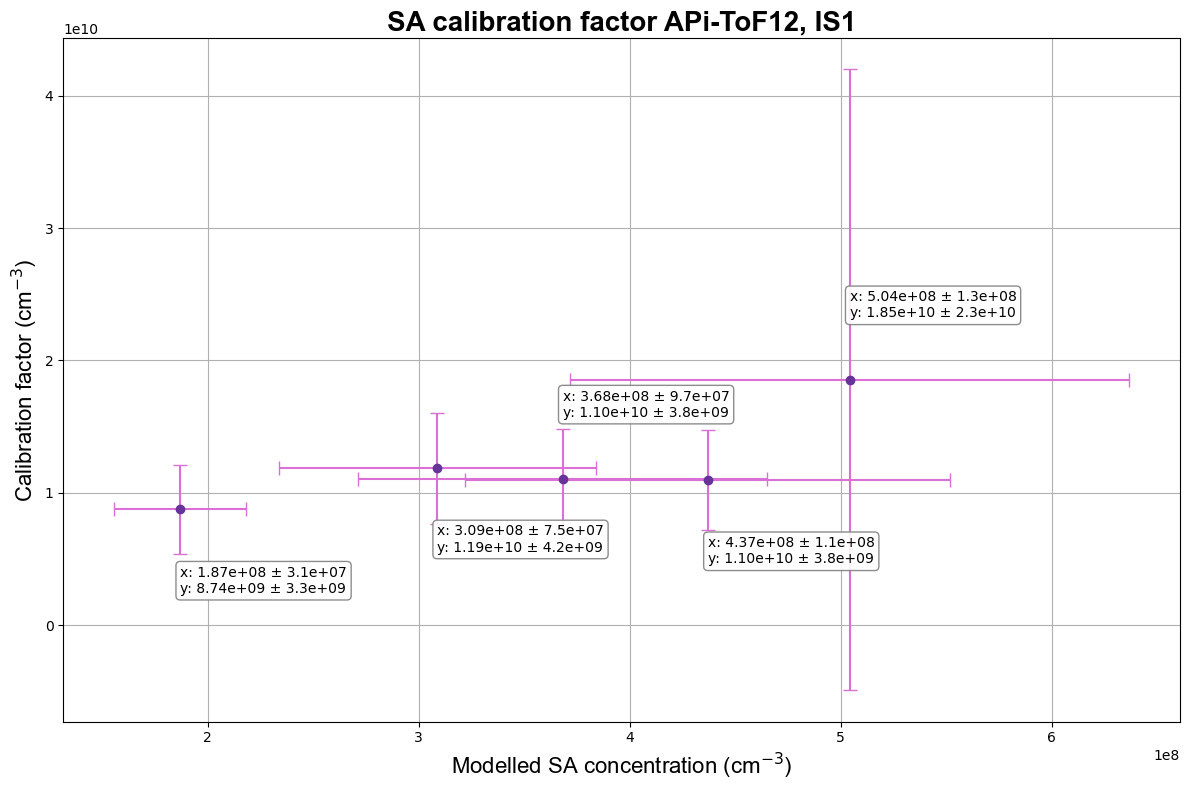

In [1]:
import numpy as np
import matplotlib.pyplot as plt

modelled_SA = [
    [1.50e8, 1.62e8, 2.18e8, 2.18e8],   # Step 1
    [1.98e8, 2.14e8, 2.26e8, 2.87e8, 3.40e8, 3.55e8, 3.86e8, 3.64e8, 4.09e8],    # Step 2
    [2.45e8, 2.45e8, 2.65e8, 2.80e8, 3.56e8, 4.20e8, 4.39e8, 4.77e8, 4.51e8, 5.05e8],   # Step 3
    [2.91e8, 2.91e8, 3.15e8, 3.32e8, 4.23e8, 4.98e8, 5.21e8, 5.66e8, 5.35e8, 5.99e8],    # Step 4
    [3.36e8, 3.36e8, 3.63e8, 3.83e8, 4.88e8, 5.75e8, 6.01e8, 6.53e8, 6.17e8, 6.91e8]    # Step 5
]

calibration_factors = [
    [7.90e9, 1.44e10, 6.64e9, 6.01e9],  # Step 1
    [7.62e9, 1.30e10, 1.27e10, 6.33e9, 5.99e9, 1.03e10, 1.19e10, 1.44e10, 1.90e10, 1.73e10],  # Step 2
    [8.28e9, 7.76e9, 1.32e10, 1.18e10, 6.10e9, 5.97e9, 9.56e9, 1.18e10, 1.25e10, 1.82e10, 1.61e10],  # Step 3
    [8.59e9, 7.83e9, 1.29e10, 1.18e10, 6.12e9, 5.60e9, 9.33e9, 1.16e10, 1.26e10, 1.80e10, 1.62e10],  # Step 4
    [8.32e9, 7.91e9, 1.37e10, 1.23e10, 6.07e9, 5.47e9, 9.17e10, 1.18e10, 1.19e10, 1.85e10, 1.61e10]  # Step 5
]

x_means = [np.mean(step) for step in modelled_SA]
x_stds = [np.std(step) for step in modelled_SA]

y_means = [np.mean(step) for step in calibration_factors]
y_stds = [np.std(step) for step in calibration_factors]

plt.figure(figsize=(12, 8))
plt.errorbar(x_means, y_means, xerr=x_stds, yerr=y_stds, fmt='o', capsize=5, color='rebeccapurple', ecolor='orchid')
plt.xlabel('Modelled SA concentration (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.ylabel('Calibration factor (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.title('SA calibration factor APi-ToF12, IS1', fontweight='bold', fontsize=20, fontname="Arial")
plt.grid(True)

# Define custom offsets for each label (x_offset, y_offset)
offsets = [
    (0, -60),    # Step 1
    (0, -60),   # Step 2
    (0, 45), # Step 3
    (0, -60),  # Step 4
    (0, 45)  # Step 5 
]

for i in range(len(x_means)):
    label = f"x: {x_means[i]:.2e} ± {x_stds[i]:.1e}\n" \
            f"y: {y_means[i]:.2e} ± {y_stds[i]:.1e}"
    plt.annotate(
        label,
        (x_means[i], y_means[i]),
        textcoords="offset points",
        xytext=offsets[i],  
        ha='left',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
    )

plt.tight_layout()
plt.show()

### APi-ToF12 IS2

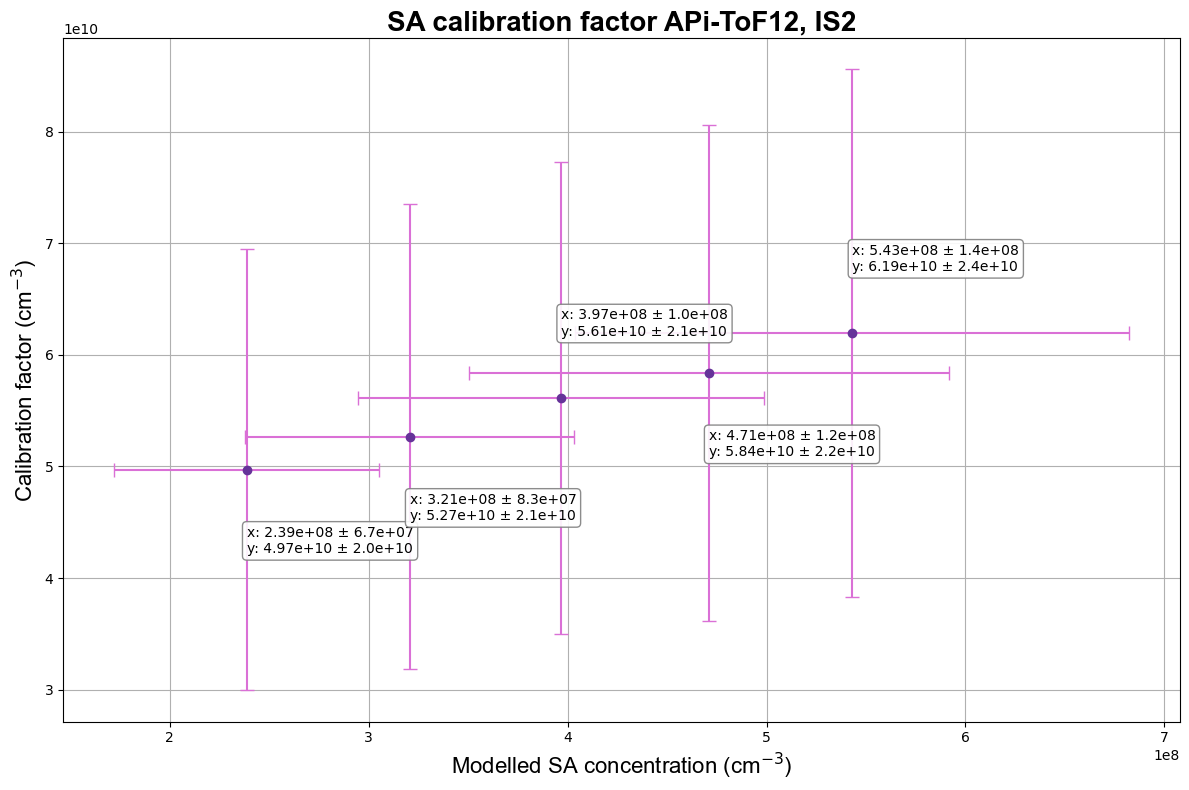

In [2]:
import numpy as np
import matplotlib.pyplot as plt

modelled_SA = [
    [1.50e8, 1.62e8, 2.18e8, 3.16e8, 2.76e8, 3.10e8],   # Step 1
    [1.98e8, 2.14e8, 2.87e8, 3.55e8, 4.17e8, 3.64e8, 4.09e8],    # Step 2
    [2.45e8, 2.65e8, 3.56e8, 4.39e8, 5.16e8, 4.51e8, 5.05e8],   # Step 3
    [2.91e8, 3.15e8, 4.23e8, 5.21e8, 6.12e8, 5.35e8, 5.99e8],    # Step 4
    [3.36e8, 3.63e8, 4.88e8, 6.01e8, 7.06e8, 6.17e8, 6.91e8]    # Step 5
]

calibration_factors = [
    [2.63e10, 4.16e10, 3.02e10, 5.02e10, 8.12e10, 6.88e10],  # Step 1
    [2.96e10, 4.46e10, 3.03e10, 4.73e10, 5.09e10, 8.89e10, 7.71e10],  # Step 2
    [3.18e10, 4.91e10, 3.36e10, 5.35e10, 5.06e10, 9.01e10, 8.42e10],  # Step 3
    [3.39e10, 5.25e10, 3.23e10, 5.60e10, 5.23e10, 9.22e10, 8.94e10],  # Step 4
    [3.58e10, 5.59e10, 3.39e10, 6.01e10, 5.52e10, 9.79e10, 9.47e10]  # Step 5
]

x_means = [np.mean(step) for step in modelled_SA]
x_stds = [np.std(step) for step in modelled_SA]

y_means = [np.mean(step) for step in calibration_factors]
y_stds = [np.std(step) for step in calibration_factors]

plt.figure(figsize=(12, 8))
plt.errorbar(x_means, y_means, xerr=x_stds, yerr=y_stds, fmt='o', capsize=5, color='rebeccapurple', ecolor='orchid')
plt.xlabel('Modelled SA concentration (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.ylabel('Calibration factor (cm$^{-3}$)', fontsize=16, fontname="Arial")
plt.title('SA calibration factor APi-ToF12, IS2', fontweight='bold', fontsize=20, fontname="Arial")
plt.grid(True)

# Define custom offsets for each label (x_offset, y_offset)
offsets = [
    (0, -60),    # Step 1
    (0, -60),   # Step 2
    (0, 45), # Step 3
    (0, -60),  # Step 4
    (0, 45)  # Step 5 
]

for i in range(len(x_means)):
    label = f"x: {x_means[i]:.2e} ± {x_stds[i]:.1e}\n" \
            f"y: {y_means[i]:.2e} ± {y_stds[i]:.1e}"
    plt.annotate(
        label,
        (x_means[i], y_means[i]),
        textcoords="offset points",
        xytext=offsets[i],  
        ha='left',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
    )

plt.tight_layout()
plt.show()